In [105]:
import os
import sys
sys.path.insert(0, "/Users/chester/Documents/cc-net")

from pathlib import Path

import time
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
import yaml

import graphlearning as gl
import sklearn.datasets as skdatasets

import models.models as Models
import losses.losses as Losses
from models.model_utils import project_l2
from datasets.dataset_utils import graphlearning_to_pyg

from tqdm.auto import tqdm


In [106]:
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = "cpu"

# Model config/checkpoint
exp_file = "./cfg-pdhg.yaml"
model_pth = "./final.pt"  # set to checkpoint .pt

# PDHG solver params
lam = None     # if None, use model_config.cfg.lam
tau = 0.35
sigma = 0.35
iters = 400
objective_rel_tol = 0.01

# 2-moons trial params
n_trials = 30
n_samples = 400
noise = 0.15
k_neighbors = 10
kernel = "gaussian"

# plotting
error_every = 10  # show error bars every N iterations

In [ ]:
def _get_sqrt_w_cached(data, ref_tensor):
    """
    Returns sqrt edge weights of shape [E], cached on `data` if possible.
    Assumes scalar edge weights.
    """
    if hasattr(data, "_sqrt_w") and data._sqrt_w is not None:
        return data._sqrt_w

    if getattr(data, "edge_attr", None) is None:
        E = data.edge_index.size(1)
        sqrt_w = torch.ones(E, device=ref_tensor.device, dtype=ref_tensor.dtype)
    else:
        w = data.edge_attr
        if w.dim() == 2 and w.size(-1) == 1:
            w = w.squeeze(-1)
        elif w.dim() != 1:
            raise ValueError("Expected scalar edge weights in edge_attr with shape [E] or [E,1].")
        sqrt_w = torch.sqrt(w.to(device=ref_tensor.device, dtype=ref_tensor.dtype).clamp_min(0.0))

    data._sqrt_w = sqrt_w
    return sqrt_w


@torch.inference_mode()
def pdhg_net_init(
    model,
    data,
    device="cpu",
    dual_init="dual_proj",   # "zero", "dual_proj", "kkt"
    lam=1.0,
    tau=1.0,
    eps=1e-12,
):
    if data.x.device.type != torch.device(device).type:
        data = data.to(device)

    x = data.x
    if x.dtype != torch.float32:
        x = x.float()

    edge_index = data.edge_index
    src, dst = edge_index

    e0 = x[src] - x[dst]

    out = model(
        h=x,
        e=e0,
        edge_index=edge_index,
        w=data.edge_attr.float(),
        x=x,
    )
    h,e = out
    for _ in range(5):    
        out = model(h=h,
                    e=e, 
                    edge_index = edge_index, 
                    w=data.edge_attr.float(),
                    x=x)
        h,e = out

    U0 = h

    # If dual dimension equals edge feature dimension, no need for P0_net
    if dual_init == "zero":
        return U0, torch.zeros_like(e0)

    sqrt_w = _get_sqrt_w_cached(data, U0)

    # Raw edge differences in primal warm start
    dU = U0[src] - U0[dst]

    if dual_init == "kkt":
        # p_e^0 = lam * sqrt(w_e) * dU_e / ||dU_e||   if dU_e != 0, else 0
        sqnorm = (dU * dU).sum(dim=-1, keepdim=True).clamp_min(eps * eps)
        inv_norm = torch.rsqrt(sqnorm)
        P0 = lam * sqrt_w.unsqueeze(-1) * dU * inv_norm

        # Zero out exact near-zero rows
        mask = sqnorm.squeeze(-1) <= eps * eps
        if mask.any():
            P0[mask] = 0
        return U0, P0

    if dual_init == "dual_proj":
        # Use scaling identity:
        # Proj_{||p|| <= lam*sqrt_w}(tau*sqrt_w*dU)
        # = sqrt_w * Proj_{||p|| <= lam}(tau*dU)
        z = tau * dU
        z_norm = z.norm(dim=-1, keepdim=True).clamp_min(eps)
        scale = torch.clamp(lam / z_norm, max=1.0)
        P0 = sqrt_w.unsqueeze(-1) * (z * scale)
        return U0, P0

    raise ValueError(f"Unknown dual_init='{dual_init}'.")

In [ ]:
def load_model(model_cfg, model_pth, device="cpu"):
    model_class = getattr(Models, model_cfg["model"])
    model = model_class(**model_cfg["cfg"]).float().to(device)

    ckpt = torch.load(model_pth, map_location=device)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state = ckpt["model_state_dict"]
    else:
        state = ckpt

    model.load_state_dict(state)
    model.eval()
    return model


def make_two_moons_graph(n_samples, noise, k_neighbors, kernel, random_state):
    X, _ = skdatasets.make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    X = X - X.mean(0)
    W = gl.weightmatrix.knn(X, k=k_neighbors, kernel=kernel)
    W.setdiag(0)
    W.eliminate_zeros()
    return graphlearning_to_pyg(X, W)


def random_init(X, m, lam, w, seed=None):
    n, d = X.shape
    U0 = torch.zeros((n,d))
    P0 = torch.zeros((m,d))
    return U0, P0


def eval_metrics(U, P, X, src, dst, w, lam):
    obj = float(Losses.energy(U, X, src, dst, w, lam).item())
    pdg = float(Losses.energy_pdg(U, X, P, src, dst, w, lam).item())
    return obj, pdg


def run_vanilla_pdhg(X, src, dst, w, lam, tau, sigma, iters, U0, P0):
    sqrtw = w.sqrt()
    n, _ = X.shape

    U = U0.clone()
    P = P0.clone()

    hist = {"obj": [], "pdg": []}
    obj, pdg = eval_metrics(U, P, X, src, dst, w, lam)
    hist["obj"].append(obj)
    hist["pdg"].append(pdg)

    r = lam * sqrtw
    for _ in range(iters):
        diff = U[src] - U[dst]
        P = project_l2(P + tau * (sqrtw[:, None] * diff), r)
        U = (U + sigma * (X - Losses.divergence(sqrtw[:, None] * P, src, dst, n))) / (1.0 + sigma)

        obj, pdg = eval_metrics(U, P, X, src, dst, w, lam)
        hist["obj"].append(obj)
        hist["pdg"].append(pdg)

    return U.detach(), P.detach(), hist


In [109]:
# Load model config
with open(exp_file, "r") as f:
    exp_cfg = yaml.safe_load(f)

model_cfg = exp_cfg["model_config"]
if lam is None:
    lam = float(model_cfg["cfg"].get("lam", 1.0))

if not model_pth:
    raise ValueError("Set model_pth to a trained PDHG-Net checkpoint.")

model = load_model(model_cfg, model_pth, device=device)
print(f"Loaded model: {model_cfg['model']}")
print(f"lam={lam}, tau={tau}, sigma={sigma}, iters={iters}")

Loaded model: EncodeProcessDecode
lam=1.0, tau=0.35, sigma=0.35, iters=400


In [110]:
methods = ["data", "random", "pdhg_net"]
results = {
    m: {
        "obj": [],
        "pdg": [],
        "init_time_s": [],
        "solve_time_s": [],
        "total_time_s": [],
    }
    for m in methods
}

trials = []
for t in range(n_trials):
    g = make_two_moons_graph(
        n_samples=n_samples,
        noise=noise,
        k_neighbors=k_neighbors,
        kernel=kernel,
        random_state=seed + t,
    )
    trials.append(g)

for t, g in enumerate(tqdm(trials, desc="Trials")):
    data = g.to(device)
    X = data.x.float()
    src, dst = data.edge_index.long()
    w = data.edge_attr.float()
    m = src.numel()
    d = X.shape[1]

    # data init
    t0 = time.perf_counter()
    U0_data, P0_data = X.clone(), torch.zeros((m, d), device=device, dtype=X.dtype)
    t_init = time.perf_counter() - t0

    t0 = time.perf_counter()
    _, _, hist_data = run_vanilla_pdhg(X, src, dst, w, lam, tau, sigma, iters, U0_data, P0_data)
    t_solve = time.perf_counter() - t0

    results["data"]["obj"].append(hist_data["obj"])
    results["data"]["pdg"].append(hist_data["pdg"])
    results["data"]["init_time_s"].append(t_init)
    results["data"]["solve_time_s"].append(t_solve)
    results["data"]["total_time_s"].append(t_init + t_solve)

    # random init
    t0 = time.perf_counter()
    U0_rand, P0_rand = random_init(X, m, lam, w, seed + t)
    t_init = time.perf_counter() - t0

    t0 = time.perf_counter()
    _, _, hist_rand = run_vanilla_pdhg(X, src, dst, w, lam, tau, sigma, iters, U0_rand, P0_rand)
    t_solve = time.perf_counter() - t0

    results["random"]["obj"].append(hist_rand["obj"])
    results["random"]["pdg"].append(hist_rand["pdg"])
    results["random"]["init_time_s"].append(t_init)
    results["random"]["solve_time_s"].append(t_solve)
    results["random"]["total_time_s"].append(t_init + t_solve)

    # pdhg-net init
    t0 = time.perf_counter()
    U0_net, P0_net = pdhg_net_init(model, g, device)
    t_init = time.perf_counter() - t0

    t0 = time.perf_counter()
    _, _, hist_net = run_vanilla_pdhg(X, src, dst, w, lam, tau, sigma, iters, U0_net, P0_net)
    t_solve = time.perf_counter() - t0

    results["pdhg_net"]["obj"].append(hist_net["obj"])
    results["pdhg_net"]["pdg"].append(hist_net["pdg"])
    results["pdhg_net"]["init_time_s"].append(t_init)
    results["pdhg_net"]["solve_time_s"].append(t_solve)
    results["pdhg_net"]["total_time_s"].append(t_init + t_solve)

Trials: 100%|██████████| 30/30 [00:10<00:00,  2.80it/s]


In [111]:
def arr(method, key):
    return np.asarray(results[method][key], dtype=np.float64)


def first_hit(curve, target):
    idx = np.where(curve <= target)[0]
    return float(idx[0]) if len(idx) > 0 else np.nan


# iterations to threshold objective
iter_summary = {m: [] for m in methods}
for t in range(n_trials):
    finals = [arr(m, "obj")[t, -1] for m in methods]
    best_final = min(finals)
    target = best_final * (1.0 + objective_rel_tol)
    for m in methods:
        iter_summary[m].append(first_hit(arr(m, "obj")[t], target))

print(f"Trials: {n_trials}, n_samples={n_samples}, noise={noise}, k={k_neighbors}")
print(f"Target objective: (1 + {objective_rel_tol:.2%}) * best final objective")
for m in methods:
    it = np.asarray(iter_summary[m], dtype=np.float64)
    print(f"{m:9s} | mean_iter={np.nanmean(it):8.2f} | median_iter={np.nanmedian(it):8.2f} | hit_rate={np.mean(~np.isnan(it)):6.2%}")

print("\nRuntime per trial (seconds, mean +/- std):")
for m in methods:
    ti = arr(m, "init_time_s")
    ts = arr(m, "solve_time_s")
    tt = arr(m, "total_time_s")
    print(f"{m:9s} | init={ti.mean():7.4f} +/- {ti.std():7.4f} | solve={ts.mean():7.4f} +/- {ts.std():7.4f} | total={tt.mean():7.4f} +/- {tt.std():7.4f}")


Trials: 30, n_samples=400, noise=0.15, k=10
Target objective: (1 + 1.00%) * best final objective
data      | mean_iter=   92.23 | median_iter=   93.00 | hit_rate=100.00%
random    | mean_iter=   96.17 | median_iter=   97.00 | hit_rate=100.00%
pdhg_net  | mean_iter=   95.43 | median_iter=   96.00 | hit_rate=100.00%

Runtime per trial (seconds, mean +/- std):
data      | init= 0.0000 +/-  0.0000 | solve= 0.1040 +/-  0.0097 | total= 0.1040 +/-  0.0097
random    | init= 0.0000 +/-  0.0000 | solve= 0.1040 +/-  0.0096 | total= 0.1040 +/-  0.0096
pdhg_net  | init= 0.0457 +/-  0.0097 | solve= 0.1029 +/-  0.0093 | total= 0.1486 +/-  0.0113


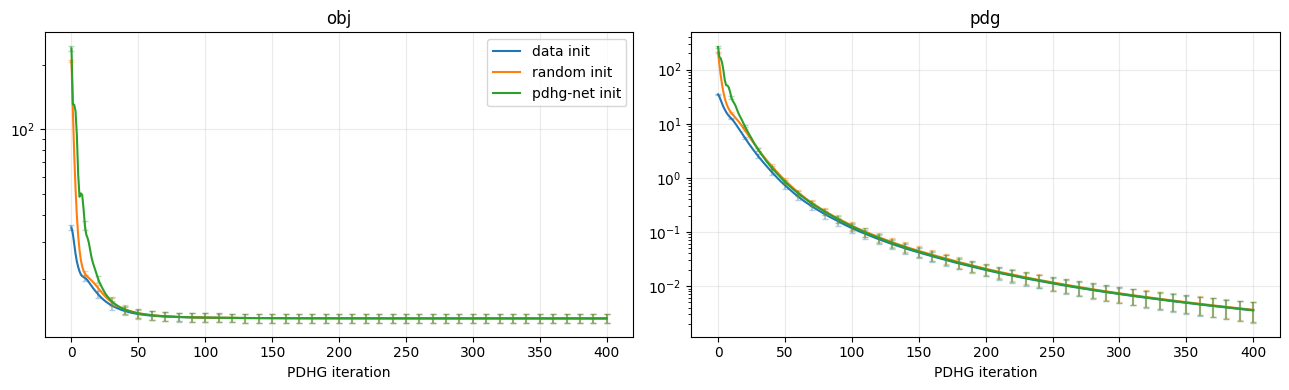

In [112]:
# mean curves with error bars across trials
colors = {"data": "tab:blue", "random": "tab:orange", "pdhg_net": "tab:green"}
labels = {"data": "data init", "random": "random init", "pdhg_net": "pdhg-net init"}

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
for metric, ax in zip(["obj", "pdg"], axs):
    for m in methods:
        #if m == 'random':
        #    continue
        A = arr(m, metric)
        mu = A.mean(axis=0)
        sd = A.std(axis=0)
        x = np.arange(A.shape[1])

        # mean curve
        ax.plot(x, mu, color=colors[m], label=labels[m])

        # error bars every error_every iter
        xe = x[::error_every]
        mue = mu[::error_every]
        sde = sd[::error_every]
        ax.errorbar(xe, mue, yerr=sde, fmt="none", ecolor=colors[m], alpha=0.35, capsize=2)

    ax.set_title(metric)
    ax.set_xlabel("PDHG iteration")
    ax.set_yscale("log")
    ax.grid(alpha=0.25)

axs[0].legend(loc="best")
plt.tight_layout()
plt.show()

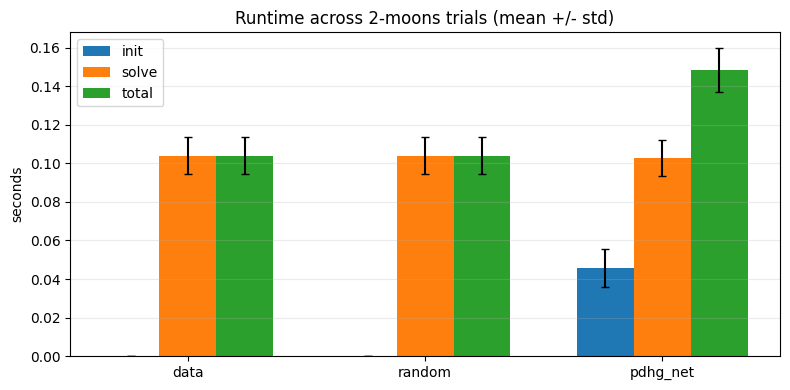

In [113]:
# runtime bars
stat_keys = ["init_time_s", "solve_time_s", "total_time_s"]
stat_names = ["init", "solve", "total"]

x = np.arange(len(methods))
width = 0.24

fig, ax = plt.subplots(figsize=(8, 4))
for i, (k, name) in enumerate(zip(stat_keys, stat_names)):
    vals = [arr(m, k).mean() for m in methods]
    errs = [arr(m, k).std() for m in methods]
    ax.bar(x + (i - 1) * width, vals, yerr=errs, capsize=3, width=width, label=name)

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("seconds")
ax.set_title("Runtime across 2-moons trials (mean +/- std)")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


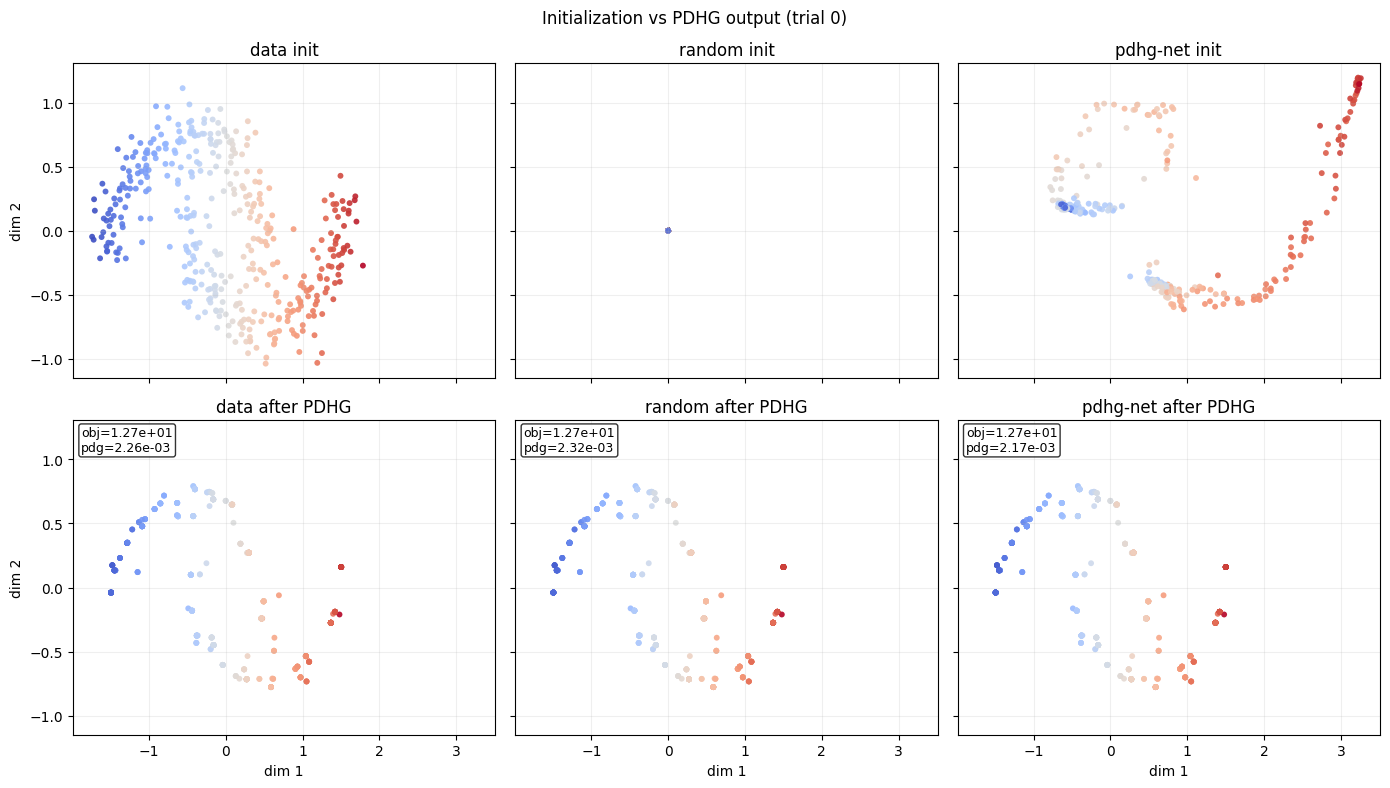

In [114]:
# visualization: initialization vs pdhg output
vis_trial = 0

if "trials" in globals() and len(trials) > 0:
    g_vis = trials[vis_trial % len(trials)]
else:
    g_vis = make_two_moons_graph(
        n_samples=n_samples,
        noise=noise,
        k_neighbors=k_neighbors,
        kernel=kernel,
        random_state=seed + vis_trial,
    )

data = g_vis.to(device)
X = data.x.float()
src, dst = data.edge_index.long()
w = data.edge_attr.float()
m = src.numel()
d = X.shape[1]

def _to_2d(U):
    U_np = U.detach().cpu().numpy()
    if U_np.shape[1] >= 2:
        return U_np[:, :2]
    z = np.zeros((U_np.shape[0], 1), dtype=U_np.dtype)
    return np.concatenate([U_np, z], axis=1)

runs = {}

U0_data = X.clone()
P0_data = torch.zeros((m, d), device=device, dtype=X.dtype)
U_data, P_data, hist_data = run_vanilla_pdhg(X, src, dst, w, lam, tau, sigma, iters, U0_data, P0_data)
runs["data"] = {"U0": U0_data, "U": U_data, "hist": hist_data}

U0_rand, P0_rand = random_init(X, m, lam, w, seed + 12345)
U_rand, P_rand, hist_rand = run_vanilla_pdhg(X, src, dst, w, lam, tau, sigma, iters, U0_rand, P0_rand)
runs["random"] = {"U0": U0_rand, "U": U_rand, "hist": hist_rand}

U0_net, P0_net = pdhg_net_init(model, g_vis, device)
U_net, P_net, hist_net = run_vanilla_pdhg(X, src, dst, w, lam, tau, sigma, iters, U0_net, P0_net)
runs["pdhg_net"] = {"U0": U0_net, "U": U_net, "hist": hist_net}

method_order = ["data", "random", "pdhg_net"]
titles = {"data": "data", "random": "random", "pdhg_net": "pdhg-net"}

X_np = X.detach().cpu().numpy()
colors = X_np[:, 0]

fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for j, method in enumerate(method_order):
    U0_plot = _to_2d(runs[method]["U0"])
    U_plot = _to_2d(runs[method]["U"])
    hist = runs[method]["hist"]

    axs[0, j].scatter(U0_plot[:, 0], U0_plot[:, 1], c=colors, cmap="coolwarm", s=18, alpha=0.9, edgecolors="none")
    axs[1, j].scatter(U_plot[:, 0], U_plot[:, 1], c=colors, cmap="coolwarm", s=18, alpha=0.9, edgecolors="none")

    axs[0, j].set_title(f"{titles[method]} init")
    axs[1, j].set_title(f"{titles[method]} after PDHG")
    axs[1, j].text(
        0.02,
        0.98,
        f"obj={hist['obj'][-1]:.2e}\npdg={hist['pdg'][-1]:.2e}",
        transform=axs[1, j].transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
    )

for ax in axs[:, 0]:
    ax.set_ylabel("dim 2")
for ax in axs[1, :]:
    ax.set_xlabel("dim 1")
for ax in axs.ravel():
    ax.grid(alpha=0.2)

plt.suptitle(f"Initialization vs PDHG output (trial {vis_trial})")
plt.tight_layout()
plt.show()
